<div style="border-bottom: 2px solid #e8a435; padding-bottom: 16px; margin-bottom: 24px;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #e8a435; font-size: 13px; font-weight: 600; letter-spacing: 0.08em; text-transform: uppercase;">Jenner Analytics &nbsp;&bull;&nbsp; Asiakasmenestysanalytiikka</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #212121; font-size: 26px; font-weight: 700; margin-top: 6px;">Asiakaspoistuman juurisyyanalyysi</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #757575; font-size: 14px; margin-top: 4px;">PROC FISHBONE -syy-seuraus-kaavio keskisuurten B2B-SaaS-yritysten pysyvyyskatsaukseen</div>
</div>

## Yhteenveto

Tämä analyysi järjestää SaaS-asiakaspoistuman kohonneiden juurisyyajureiden joukon jäsennellyksi syy-seuraus- (Ishikawa-) kaavioksi. Keskisuurten B2B-yritysten segmentti poistuu noin 18 %:n vuosivauhtia 8 %:n tavoitetta vastaan. Kaksikymmentä juurisyylöydöstä — jotka on koottu lähtökyselyistä, asiakasmenestyshaastatteluista ja kohorttiattribuutiosta — ryhmitellään kuuteen syykategoriaan ja piirretään `PROC FISHBONE` -menetelmällä 27-solmuisena kaaviona (yksi seuraus, kuusi kategoriaruotoa, kaksikymmentä alasyytä).

Tukeva `PROC MEANS` -erittely näyttää, minne attribuoitava poistuma keskittyy. **Tuote** kantaa eniten löydöksiä (5 syytä, 48,1 vaikutuspistettä yhteensä), sitä seuraavat **Hinnoittelu** (4 syytä, 42,3) ja **Tuki** (4 syytä, 40,2). Keskimääräisellä vaikutuksella *syytä kohti* mitattuna **Kilpailu** on vakavin kategoria (keskiarvo 11,8), ja yksittäinen suurimman vaikutuksen löydös kaikkiaan on **Hinnoittelun** uusinnan korotus ilman ennakkovaroitusta (14,2). `PROC SGPLOT` -Pareto-näkymä järjestää jokaisen yksittäisen syyn, jotta johto näkee, mihin ruotoihin puuttua ensin. Tuotos syöttää asiakasmenestyksen neljännesvuosittaisen pysyvyyskatsauksen.

## Tietolähteet

| Lähde | Kuvaus | Tietueita |
|--------|-------------|--------|
| WORK.CHURN_RCA | Asiakaspoistuman juurisyylöydökset koottuna lähtökyselyanalyysistä ja asiakasmenestystiimin retrospektiivistä; jokainen rivi on yksi syy kategorioineen, tukevine todisteineen ja arvioituine poistumavaikutusosuuksineen | 20 |

---

In [1]:
/* --------------------------------------------------------
   Asiakaspoistuman juurisyylöydökset (RCA)
   SaaS-alusta, B2B keskisuurten yritysten segmentti.
   Jokainen rivi: syykategoria, tietty syy, tukeva
   alasyy/todiste sekä arvioitu poistuman osuus, joka
   sille voidaan attribuoida (lähtökyselystä ja
   kohorttiattribuutiosta).
   -------------------------------------------------------- */
TIEDOT work.churn_rca;
    INFILE DATALINES dlm='|' dsd truncover;
    SYÖTE category :$40. cause :$160. subcause :$220. churn_impact_pct;
    DATALINES;
Tuote|Ydinominaisuuksien puutteet yritystason kilpailijoihin nähden|Joukkovienti ja API-kutsurajat mainittu 34 %:ssa lähtökyselyistä|12.4
Tuote|Raportointiominaisuudet rajalliset|Vakiotasolla ei mukautettavaa koontinäyttöjen rakennustyökalua|9.8
Tuote|Mobiilisovellus jäljessä verkkoversion toiminnoista|Kolme keskeistä työnkulkua, joita pelkät mobiilikäyttäjät eivät voi suorittaa|8.2
Tuote|Tiheät käyttöliittymämuutokset ilman ennakkoilmoitusta|Tehokäyttäjiä häiritsevät neljännesvuosittaiset uudistukset|7.6
Tuote|Integraatiokaupan puutteet|Puuttuvat Salesforce- ja HubSpot-natiiviliitännät|10.1
Hinnoittelu|Uusinnan hinnankorotus ilman ennakkovaroitusta|18 %:n MRR-korotus 30 päivän varoitusajalla|14.2
Hinnoittelu|Käyttäjäkohtainen malli rankaisee tiimin kasvusta|Kustannus kaksinkertaistuu tiimin kasvaessa 10:stä 20:een|11.3
Hinnoittelu|Aloitusalennus ei uusittavissa|Hintashokki ensimmäisessä uusinnassa|9.7
Hinnoittelu|Ei kannustinta monivuotiseen sopimukseen|Vuosihinta sama kuin kuukausittain|7.1
Tuki|Ensivasteaika ylittää 24 tuntia|Tasovertailuarvo on 4 tuntia|10.8
Tuki|Viikonlopputuen laatuvaje|Ulkomaisella päivystyksellä ei tuotetuntemusta|9.3
Tuki|Ei nimettyä CSM:ää Enterprise-tason alapuolella|Keskisuurilla asiakkuuksilla ei nimettyä yhteyshenkilöä|11.5
Tuki|Eskalointipolku epäselvä asiakkaille|38 % poistuneista asiakkuuksista mainitsi eskaloinnin sekavuuden|8.6
Käyttöönotto|Arvon saavuttamisaika ylittää 90 päivää|Käyttöönoton monimutkaisuutta ei kerrottu ennen kauppaa|12.9
Käyttöönotto|Itsepalveludokumentaatio vanhentunut|Päivitetty viimeksi 11 kuukautta sitten|8.1
Käyttöönotto|Ei sovelluksen sisäisiä opastuksia uusille ominaisuuksille|Ominaisuuksien käyttöönotto alle 30 % kuudessa kuukaudessa|9.4
Kilpailu|Kilpailija 30 % halvemmalla hinnalla|Kolme suurta asiakkuutta mainitsi tietyn kilpailijan|13.1
Kilpailu|Kilpailija tarjoaa rajattoman käyttäjämäärän hinnoittelun|Poistaa käyttäjäkohtaisen rangaistuksen kasvaville tiimeille|10.6
Asiakassuhde|Johdon sponsorin vaihtuvuutta ei hallita|Puolestapuhuja lähti; ei uudelleenaktivointiohjelmaa|11.7
Asiakassuhde|QBR-tahti harvennettu vuosittaiseksi|Asiakasmenestystiimin resurssileikkaus 18 kuukautta sitten|9.2
;
SUORITA;


NOTE: DATA work.churn_rca

NOTE: Processing inline DATALINES (20 lines)

NOTE: Read 20 rows from DATALINES.
NOTE: Wrote work.churn_rca (20 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


---

In [2]:
/* --------------------------------------------------------
   Perustaso: poistumavaikutuksen keskittyminen
   RCA-kategorioittain. Summa näyttää, minne attribuoitava
   poistuma klusteroituu; maksimi merkitsee kunkin
   kategorian pahimman yksittäisen syyn.
   -------------------------------------------------------- */
PROSEDUURI KESKIARVOT TIEDOT=work.churn_rca n sum mean MAX maxdec=1;
    LUOKKA category;
    MUUTTUJA churn_impact_pct;
    NIMIKE category='Syykategoria' churn_impact_pct='Arvioitu poistumavaikutus (%)';
    OTSIKKO 'Asiakaspoistuman juurisyyanalyysi: vaikutusprosentti kategorioittain';
SUORITA;

                          Asiakaspoistuman juurisyyanalyysi: vaikutusprosentti kategorioittain                          

                                                  The MEANS Procedure

                           Analysis Variable : churn_impact_pct Arvioitu poistumavaikutus (%)

        Syykategoria             N Obs            Sum           Mean        Maximum
        ---------------------------------------------------------------------------
        Asiakassuhde                 2           20.9           10.4           11.7
        Hinnoittelu                  4           42.3           10.6           14.2
        Kilpailu                     2           23.7           11.8           13.1
        Käyttöönotto                 3           30.4           10.1           12.9
        Tuki                         4           40.2           10.1           11.5
        Tuote                        5           48.1            9.6           12.4
        --------------------------------


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

                          Asiakaspoistuman juurisyyanalyysi: vaikutusprosentti kategorioittain                          




NOTE: PROC SORT data=work.churn_rca

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 20 rows from work.churn_rca.
NOTE: Wrote work.churn_rca (20 rows, 4 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SGPLOT data=work.churn_rca

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


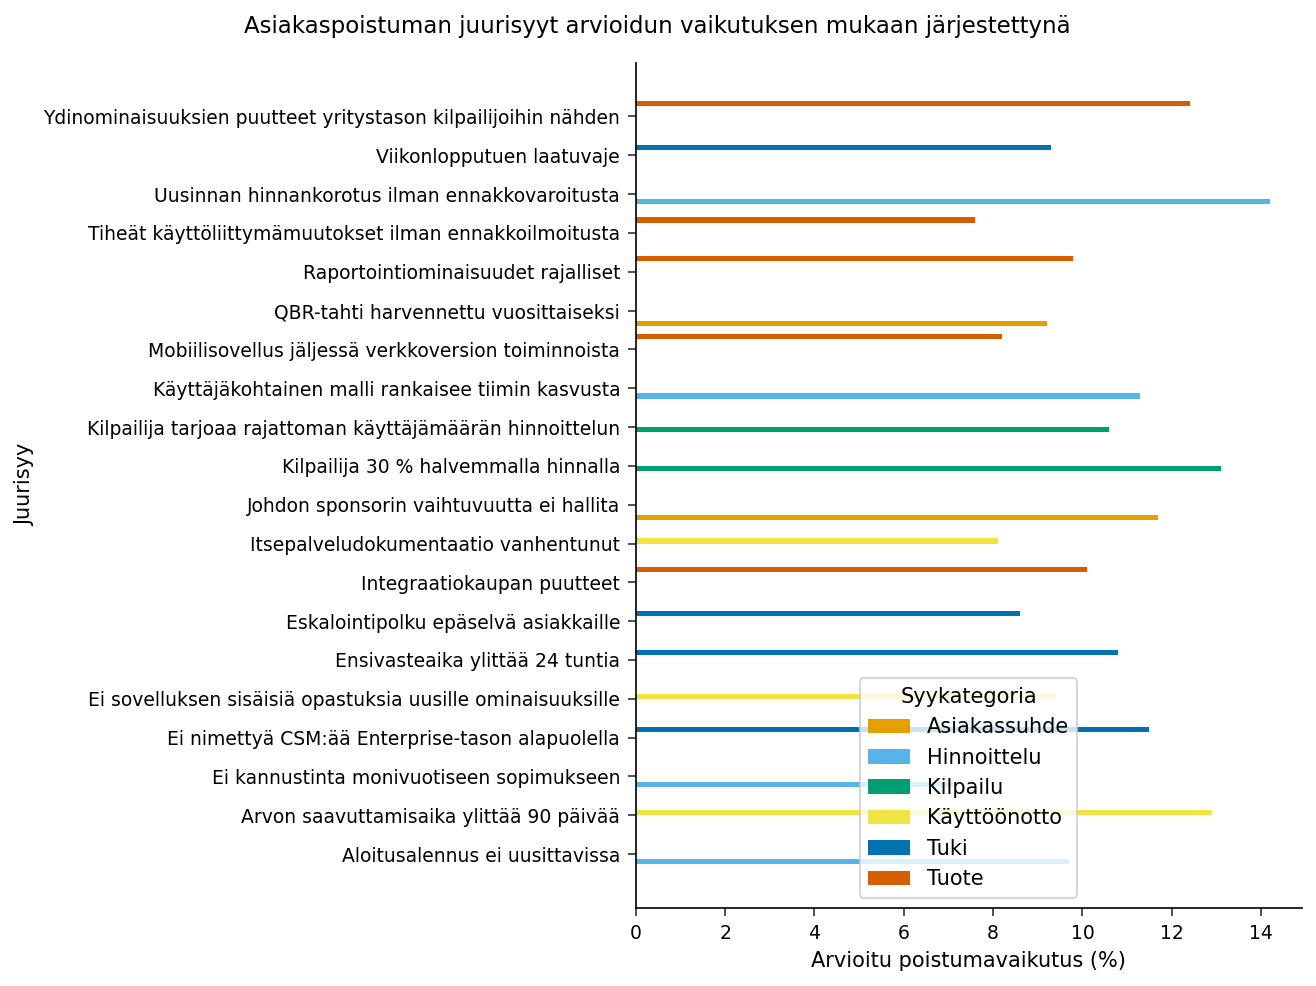

In [3]:
/* --------------------------------------------------------
   Pareto-näkymä: yksittäiset juurisyyt arvioidun
   poistumavaikutuksen mukaan järjestettyinä, kategorian
   mukaan väritettyinä. Tämä täydentää kalanruotokaaviota
   kvantifioimalla, mitkä ruodot ovat tärkeimpiä.
   -------------------------------------------------------- */
PROSEDUURI LAJITTELE TIEDOT=work.churn_rca;
    MUKAAN LASKEVA churn_impact_pct;
SUORITA;

PROSEDUURI SGPLOT TIEDOT=work.churn_rca;
    HBAR cause / RESPONSE=churn_impact_pct
        GROUP=category;
    xaxis label='Arvioitu poistumavaikutus (%)';
    yaxis label='Juurisyy' discreteorder=data;
    keylegend / title='Syykategoria' position=bottom;
    OTSIKKO 'Asiakaspoistuman juurisyyt arvioidun vaikutuksen mukaan järjestettynä';
SUORITA;

---

### Syy-seuraus- (Ishikawa-) kaavio

`PROC FISHBONE` rakentaa kaavion suoraan `WORK.CHURN_RCA`:sta: jokaisesta erillisestä `category`-arvosta tulee pääruoto keskirangasta, ja yksittäiset `cause`-löydökset riippuvat kategoriaruodostaan alasyinä. Proseduuri tulostaa täyden syy-seuraus-rakenteen alle — seuraus kärjessä, kuusi kategoriaruotoa ja jokainen alasyy ryhmiteltynä ruotonsa alle — ja kirjoittaa vastaavan kalanruotografiikan levylle. Yllä oleva järjestetty Pareto-kaavio on täydentävä näkymä, joka kvantifioi, mikä näistä ruodoista kantaa eniten attribuoitavaa poistumaa.

In [4]:
/* --------------------------------------------------------
   PROC FISHBONE: asiakaspoistuman syy-seuraus-kaavio.
   Kaavio muodostetaan suoraan WORK.CHURN_RCA:sta, joten
   kuusi syykategoriaa ja niiden syyt ovat täsmälleen
   edellä analysoidut löydökset. CATEGORY muodostaa
   pääruodot; CAUSE riippuu alasyinä kustakin ruodosta.
   -------------------------------------------------------- */
PROSEDUURI fishbone TIEDOT=work.churn_rca;
    cause category / subcause=cause;
    effect 'Kohonnut asiakaspoistuma (18 % vuodessa vs. 8 %:n tavoite)';
    OTSIKKO 'Asiakaspoistuman juurisyyanalyysi - keskisuurten yritysten segmentti';
    footnote 'Lähteet: lähtökyselyt, asiakasmenestystiimin haastattelut, kohorttiattribuutio';
SUORITA;

                          Asiakaspoistuman juurisyyanalyysi: vaikutusprosentti kategorioittain                          


                    Asiakaspoistuman juurisyyanalyysi - keskisuurten yritysten segmentti
                    The FISHBONE Procedure

  Cause-and-Effect Diagram

  [EFFECT] Kohonnut asiakaspoistuma (18 % vuodessa vs. 8 %:n tavoite)
    [CAUSE] Hinnoittelu (top)
      [SUB] Uusinnan hinnankorotus ilman ennakkovaroitusta
      [SUB] Käyttäjäkohtainen malli rankaisee tiimin kasvusta
      [SUB] Aloitusalennus ei uusittavissa
      [SUB] Ei kannustinta monivuotiseen sopimukseen
    [CAUSE] Kilpailu (top)
      [SUB] Kilpailija 30 % halvemmalla hinnalla
      [SUB] Kilpailija tarjoaa rajattoman käyttäjämäärän hinnoittelun
    [CAUSE] Käyttöönotto (top)
      [SUB] Arvon saavuttamisaika ylittää 90 päivää
      [SUB] Ei sovelluksen sisäisiä opastuksia uusille ominaisuuksille
      [SUB] Itsepalveludokumentaatio vanhentunut
    [CAUSE] Tuote (bottom)
      [SUB] Ydinominais


NOTE: PROC FISHBONE
NOTE: PROC FISHBONE: wrote SVG to ./actual/fishbone.svg
NOTE: Output dataset has 27 nodes


---

### Tulkinta

Syy-seuraus-rakenne ja kategoriakohtaiset `PROC MEANS` -luvut ohjaavat johdon pieneen määrään suurivaikutteisia toimia. Kaksi suurinta yksittäistä syylöydöstä — **Hinnoittelun** uusinnan korotus ilman varoitusta (14,2) ja **Kilpailun** löydös, että kilpailija myy vastaavan kyvykkyyden 30 % halvemmalla (13,1) — ovat molemmat kaupallisia eivätkä tuotekysymyksiä, mikä viittaa siihen, että hinnoittelun läpinäkyvyys ja kilpailullinen asemointi ovat kiireellisimmät lähiajan vipuvarret. **Käyttöönoton** yli 90 päivän arvonsaavuttamisaika (12,9) on suurin palvelupuolen löydös ja liittyy suoraan myyntiä edeltävään odotusten asettamiseen.

Määrällisesti **Tuote** hallitsee kaaviota (5 löydöstä 20:stä, 48,1 vaikutuspistettä yhteensä), mutta sen löydökset ovat yksittäin pienempiä (keskiarvo 9,6) kuin **Kilpailun** (keskiarvo 11,8) tai **Hinnoittelun** (keskiarvo 10,6) — muistutus siitä, ettei pitkä lista tuotepuutteita ole automaattisesti tärkein prioriteetti. **Asiakassuhde**-ruoto (johdon sponsorin vaihtuvuus ja harvennettu QBR-tahti, 20,9 yhteensä) edustaa prosessimuutoksia, jotka asiakasmenestystiimi voi toteuttaa kuluvan vuosineljänneksen aikana ilman tuote- tai hinnoitteluinvestointia, tarjoten nopeimman polun mitattavaan pysyvyyden paranemiseen. Pareto-kaavion täysi järjestetty lista antaa johtoryhmän jaksottaa toimenpiteet arvioidun vaikutuksen mukaan kategorian koon sijaan.

---

In [5]:
/* --------------------------------------------------------
   Vie asiakaspoistuman RCA-löydökset strategiakatsauksen
   esitystä varten
   -------------------------------------------------------- */
PROSEDUURI VIE TIEDOT=work.churn_rca
    OUTFILE='customer_churn_rca_findings.csv'
    DBMS=csv REPLACE;
SUORITA;


NOTE: PROC EXPORT data=work.churn_rca outfile=customer_churn_rca_findings.csv

NOTE: Exported 20 rows to customer_churn_rca_findings.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Luottamuksellinen
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Toteutettu <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>-alustalla
</div>
</div>